In [45]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from pathlib import Path
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, random_split, TensorDataset

from google.colab import drive
drive.mount('/content/drive')
DATA_DIR = Path("/content/drive/MyDrive/prf_data")

print("torch:", torch.__version__)
device = "cpu"  # For fixed, reproducible results. (You may switch to "cuda" after you finish debugging.)
print("device:", device)

def set_seed(seed: int = 42):
    """Make results as reproducible as possible across runs."""

    os.environ["PYTHONHASHSEED"] = str(seed)
    # If you later switch to CUDA and want maximal determinism:
    # os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Deterministic flags (safe on CPU; on GPU some ops may error if non-deterministic)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    try:
        torch.use_deterministic_algorithms(True)
    except Exception as e:
        print("Warning: could not enable full deterministic algorithms:", e)

set_seed(42)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
torch: 2.10.0+cpu
device: cpu


In [46]:
class SlipSlop(nn.Module):
    def __init__(self, n_channels=7, seq_len=250):
        super().__init__()
        self.features = nn.Sequential(nn.Conv1d(in_channels=n_channels, out_channels=32, kernel_size=7,stride=1,padding=3),
                                      nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(kernel_size=2, stride=2, padding=0),
                                      nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5,stride=1,padding=2),
                                      nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(kernel_size=2, stride=2, padding=0),
                                      nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3,stride=1,padding=1),
                                      nn.BatchNorm1d(128), nn.ReLU())
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.max_pool = nn.AdaptiveMaxPool1d(1)
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(in_features=256, out_features=256, bias=True),
                                        nn.ReLU(), nn.Dropout(0.3), nn.Linear(in_features=256, out_features=1, bias=True))

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.features(x)
        avg = self.avg_pool(x)
        mx = self.max_pool(x)
        x = torch.cat([avg, mx], dim=1)
        x = self.classifier(x)
        return x

model = SlipSlop().to(device)
print(model)
num_params = sum(p.numel() for p in model.parameters())
print("Total params:", num_params)

SlipSlop(
  (features): Sequential(
    (0): Conv1d(7, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (avg_pool): AdaptiveAvgPool1d(output_size=1)
  (max_pool): AdaptiveMaxPool1d(output_size=1)
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=256, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, in

In [55]:
DATA_DIR = Path("/content/drive/MyDrive/prf_data")
batch_size = 128
num_workers = 0

data = np.load(DATA_DIR / "prf_dataset.npz")
X_train = torch.FloatTensor(data["X_train"])
y_train = torch.FloatTensor(data["y_train"])
X_val = torch.FloatTensor(data["X_val"])
y_val = torch.FloatTensor(data["y_val"])
X_test = torch.FloatTensor(data["X_test"])
y_test = torch.FloatTensor(data["y_test"])

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
pos_weight = torch.tensor([n_neg / n_pos * 2]).to(device)
print(f"Positive weight of {pos_weight}")
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print("train/val/test:", len(train_dataset), len(val_dataset), len(test_dataset))

Positive weight of tensor([9.5230])
train/val/test: 59021 7378 7379


In [56]:
def train_one_epoch(model, loader):
    """Train for one epoch and return (avg_loss, accuracy)."""
    loss_list = []
    correct_total = 0
    count_total = 0
    model.train()

    pbar = tqdm(loader)

    for train_features, train_labels in pbar:
        train_features, train_labels = train_features.to(device), train_labels.to(device)

        logits = model(train_features).squeeze(-1)
        loss = criterion(logits, train_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        probs = torch.sigmoid(logits.detach())
        preds = (probs >= 0.5).float()
        correct_total += (preds == train_labels).sum().item()
        count_total += train_labels.size(0)
        loss_list.append(loss.item())

    return np.mean(loss_list), 100 * correct_total / count_total

In [ ]:
@torch.no_grad()
def val_evaluate(model, loader):
    """Evaluate model and return (avg_loss, accuracy)."""
    loss_list = []
    correct_total = 0
    count_total = 0
    model.eval()

    pbar = tqdm(loader)

    for val_features, val_labels in pbar:
        val_features, val_labels = val_features.to(device), val_labels.to(device)
        logits = model(val_features).squeeze(-1)
        loss = criterion(logits, val_labels)

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()
        correct_total += (preds == val_labels).sum().item()
        count_total += val_labels.size(0)
        loss_list.append(loss.item())

    return np.mean(loss_list), 100 * correct_total / count_total

In [ ]:
@torch.no_grad()
def test_evaluate(model, loader):
    """Evaluate model with sigmoid probabilities. Returns loss, accuracy, precision, recall, F1."""
    all_probs = []
    all_labels = []
    loss_list = []
    model.eval()

    pbar = tqdm(loader)

    for features, labels in pbar:
        features, labels = features.to(device), labels.to(device)
        logits = model(features).squeeze(-1)       # raw output, no sigmoid
        loss = criterion(logits, labels)
        loss_list.append(loss.item())

        probs = torch.sigmoid(logits)              # apply sigmoid for probabilities
        all_probs.append(probs.cpu())
        all_labels.append(labels.cpu())

    all_probs = torch.cat(all_probs)
    all_labels = torch.cat(all_labels)
    preds = (all_probs >= 0.5).float()             # threshold at 0.5

    # Metrics
    correct = (preds == all_labels).sum().item()
    total = len(all_labels)
    accuracy = 100 * correct / total

    tp = ((preds == 1) & (all_labels == 1)).sum().item()
    fp = ((preds == 1) & (all_labels == 0)).sum().item()
    fn = ((preds == 0) & (all_labels == 1)).sum().item()

    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-8)

    avg_loss = np.mean(loss_list)

    print(f"  Loss:      {avg_loss:.4f}")
    print(f"  Accuracy:  {accuracy:.2f}%")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1:        {f1:.4f}")
    print(f"  TP: {tp}  FP: {fp}  FN: {fn}")

    return avg_loss, accuracy, precision, recall, f1, all_probs, all_labels

In [57]:
epochs = 10
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
best_epoch = -1
ckpt_path = "./checkpoints/best_prf_cnn.pt"
os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)

for epoch in range(epochs):
  train_loss, train_acc = train_one_epoch(model, train_loader)
  val_loss, val_acc = val_evaluate(model, val_loader)

  history["train_loss"].append(train_loss)
  history["train_acc"].append(train_acc)
  history["val_loss"].append(val_loss)
  history["val_acc"].append(val_acc)

  # Save only if we improve
  if val_acc > best_val_acc:
    best_val_acc = val_acc
    best_epoch = epoch
    torch.save({
        'model_state_dict': model.state_dict(),
        'epoch': epoch
     }, ckpt_path)

  print(f"Epoch: {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
  print(f"Current best: {best_val_acc:.2f}% at epoch {best_epoch+1}")

print("Final Best val acc:", best_val_acc, "at epoch", best_epoch)
print("Saved to:", ckpt_path)

  0%|          | 0/3689 [00:00<?, ?it/s]

  0%|          | 0/462 [00:00<?, ?it/s]

Epoch: 1/10 | Train Loss: 0.7868 | Val Loss: 0.4531 | Val Acc: 91.41%
Current best: 91.41% at epoch 1


  0%|          | 0/3689 [00:00<?, ?it/s]

  0%|          | 0/462 [00:00<?, ?it/s]

...

  0%|          | 0/462 [00:00<?, ?it/s]

Epoch: 9/10 | Train Loss: 0.0940 | Val Loss: 0.1342 | Val Acc: 98.16%
Current best: 98.16% at epoch 9


  0%|          | 0/3689 [00:00<?, ?it/s]

  0%|          | 0/462 [00:00<?, ?it/s]

Epoch: 10/10 | Train Loss: 0.0786 | Val Loss: 0.2406 | Val Acc: 98.48%
Current best: 98.48% at epoch 10
Final Best val acc: 98.4819734345351 at epoch 9
Saved to: ./checkpoints/best_prf_cnn.pt


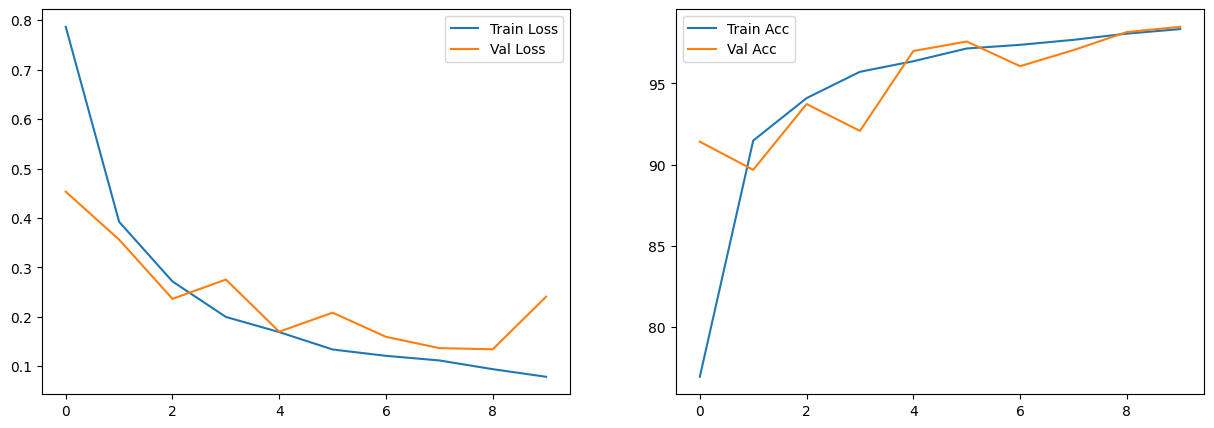

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
train_loss = history["train_loss"]
val_loss = history["val_loss"]
train_acc = history["train_acc"]
val_acc = history["val_acc"]
axes[0].plot(train_loss, label="Train Loss")
axes[0].plot(val_loss, label="Val Loss")
axes[1].plot(train_acc, label="Train Acc")
axes[1].plot(val_acc, label="Val Acc")
axes[0].legend()
axes[1].legend()
plt.show()

In [60]:
checkpoint = torch.load(ckpt_path)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
with torch.no_grad():
  test_loss, test_acc, _, _, f1, _, _ = test_evaluate(model, test_loader)

print(f"Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f} | F1 Score: {f1}")

  0%|          | 0/462 [00:00<?, ?it/s]

  Loss:      0.2838
  Accuracy:  98.39%
  Precision: 0.9582
  Recall:    0.9485
  F1:        0.9533
  TP: 1215  FP: 53  FN: 66
Test loss: 0.2838 | Test acc: 98.3873 | F1 Score: 0.9533150255001963
